# 11 — 長期記憶：`BaseStore`

**這份要學什麼**
- `BaseStore` / `InMemoryStore`：跨對話串（不同 thread_id）的長期記憶
- 跟 `06` 的 checkpointer（短期記憶）差在哪裡、怎麼同時掛在同一個 graph 上

> 不需要 API key。這份的機制完全跟 LLM 無關（跟 `06`、`07` 一樣），純粹是 LangGraph
> 執行引擎本身的能力。

`06_langgraph_memory_checkpoint.ipynb` 教的 checkpointer 有一個邊界：它記的是
**「同一個 `thread_id`」範圍內**的狀態。換一個 `thread_id`（等於開了一個新對話串），
checkpointer 完全不知道之前那個對話串發生過什麼。

但現實中你常常需要「跨對話串」的記憶——例如：使用者這次對話說了他叫什麼名字、偏好用什麼
語言，你希望**下次開新對話**時 agent 還記得。這種記憶不屬於任何一個 `thread_id`，
屬於這個使用者本人。LangGraph 用一個獨立於 checkpointer 的機制處理這件事：**`BaseStore`**。

## 核心概念：`namespace` + `key` → `value`

`BaseStore` 是一個很單純的 key-value store，多了一層「命名空間」方便分類：

- **`namespace`**：一個 tuple，像資料夾路徑，例如 `("users", "u1")` 代表「使用者 u1 的資料」
- **`key`**：命名空間底下的鍵，例如 `"profile"`
- **`value`**：一個 dict，實際存的內容

`InMemoryStore` 是最簡單的實作（跟 `06` 的 `InMemorySaver` 是同一個精神：只存在行程
記憶體裡，程式關掉就消失）。

In [1]:
from langgraph.store.memory import InMemoryStore

store = InMemoryStore()

store.put(("users", "u1"), "profile", {"name": "Vincent", "preferred_language": "zh-TW"})

item = store.get(("users", "u1"), "profile")
print(item.value)
print("建立時間:", item.created_at)

{'name': 'Vincent', 'preferred_language': 'zh-TW'}
建立時間: 2026-09-10 02:23:17.419316+00:00


## 接進 graph：`compile(store=...)` + `get_store()`

跟 checkpointer 一樣，`store` 是在 `compile()` 時掛上去的。node 裡面要拿到它，用
`langgraph.config.get_store()`——不用像參數一樣手動傳遞，它是透過 context 自動取得
目前這次執行掛的 store，跟 `07` 的 `interrupt()` 是同一種「不用手動傳參數」的設計。

下面這個例子刻意把 `user_id` 放進 `config`（跟 `thread_id`分開），示範記憶怎麼跨
`thread_id` 但綁定在同一個 `user_id` 上：使用者在對話串 A 自我介紹，換到全新的對話串 B
（不同 `thread_id`），agent 還記得他是誰；換一個不同的使用者，則完全不會記得。

**陷阱**：node 想拿到 `config`（裡面帶了 `user_id`），第二個參數的型別標注要用
`RunnableConfig`，標成單純的 `dict` LangGraph 不會辨識出這是要注入的 config，會直接
報 `missing 1 required positional argument`——這是實際測試撞到才發現的，型別標注
在這裡不是裝飾用的，是 LangGraph 用來判斷簽名的依據。

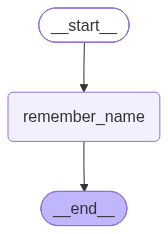

In [2]:
import sys

sys.path.insert(0, ".")
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.config import get_store
from langgraph.graph import END, START, MessagesState, StateGraph

from _graph_viz import show_graph


def remember_name(state: MessagesState, config: RunnableConfig) -> dict:
    store = get_store()
    user_id = config["configurable"]["user_id"]
    last = state["messages"][-1].content

    if last.startswith("我叫"):
        name = last.removeprefix("我叫")
        store.put(("users", user_id), "profile", {"name": name})
        return {"messages": [("ai", f"記住了，你是 {name}")]}

    item = store.get(("users", user_id), "profile")
    name = item.value["name"] if item else "陌生人"
    return {"messages": [("ai", f"哈囉 {name}")]}


builder = StateGraph(MessagesState)
builder.add_node("remember_name", remember_name)
builder.add_edge(START, "remember_name")
builder.add_edge("remember_name", END)

graph = builder.compile(checkpointer=InMemorySaver(), store=InMemoryStore())
show_graph(graph)

In [3]:
# 對話串 A：使用者自我介紹
r1 = graph.invoke(
    {"messages": [("human", "我叫Vincent")]},
    {"configurable": {"thread_id": "thread-A", "user_id": "u1"}},
)
print("thread-A:", r1["messages"][-1].content)

# 對話串 B：全新的 thread_id，但同一個 user_id -> 應該還記得名字
r2 = graph.invoke(
    {"messages": [("human", "你還記得我嗎")]},
    {"configurable": {"thread_id": "thread-B", "user_id": "u1"}},
)
print("thread-B（同一個 user_id）:", r2["messages"][-1].content)

# 對話串 C：不同的 user_id -> 不會記得
r3 = graph.invoke(
    {"messages": [("human", "你還記得我嗎")]},
    {"configurable": {"thread_id": "thread-C", "user_id": "u2"}},
)
print("thread-C（不同 user_id）:", r3["messages"][-1].content)

thread-A: 記住了，你是 Vincent
thread-B（同一個 user_id）: 哈囉 Vincent
thread-C（不同 user_id）: 哈囉 陌生人


`thread-A` 跟 `thread-B` 是兩個完全獨立的 checkpointer 對話狀態（`06` 教的機制），
但因為 `store` 是跨 `thread_id` 共用的，只要 `user_id` 一樣就查得到同一筆資料——
這就是長期記憶跟短期記憶的本質差異。

## `search()`：依條件列出/篩選

`namespace_prefix` 可以只給前面幾段（例如只給 `("users",)`），列出底下所有項目；
`filter` 可以依 value 裡的欄位篩選，不需要語意搜尋（要做語意搜尋才需要另外設定
`index`/embeddings，這裡先不涉及，避免又要接 API key）。

In [4]:
store.put(("users", "u2"), "profile", {"name": "Alice", "preferred_language": "en"})

print("所有使用者:")
for result in store.search(("users",)):
    print(" ", result.namespace, "->", result.value)

print("只找偏好 zh-TW 的:")
for result in store.search(("users",), filter={"preferred_language": "zh-TW"}):
    print(" ", result.namespace, "->", result.value)

所有使用者:
  ('users', 'u1') -> {'name': 'Vincent', 'preferred_language': 'zh-TW'}
  ('users', 'u2') -> {'name': 'Alice', 'preferred_language': 'en'}
只找偏好 zh-TW 的:
  ('users', 'u1') -> {'name': 'Vincent', 'preferred_language': 'zh-TW'}


## Checkpointer vs Store：對照表

| | Checkpointer（`06`） | Store（這份） |
|---|---|---|
| 記憶範圍 | 單一 `thread_id`（一個對話串） | 跨 `thread_id`，依你自訂的 namespace（通常是 user_id） |
| 存的是什麼 | 整個 graph state 的每一步快照 | 你自己決定要存的任意 dict |
| 怎麼寫入 | node 回傳值，經 reducer 自動合併 | node 裡手動呼叫 `store.put()` |
| 怎麼讀取 | 自動載入成下一次 invoke 的初始 state | node 裡手動呼叫 `store.get()` / `search()` |
| 用途 | 恢復對話上下文、`interrupt()` 的暫停/恢復 | 使用者偏好、跨對話事實、長期知識庫 |

兩者是正交的——一個 graph 可以同時掛 `checkpointer` 又掛 `store`，各自負責不同層次的記憶,
上面的例子就是兩個一起掛著用。

## 持久化後端：`SqliteStore`

跟 `10` 的 `SqliteSaver` 對稱，`langgraph-checkpoint-sqlite`（這個 repo 已經裝了）同一個
套件裡也附了 `SqliteStore`——`InMemoryStore` 換成它，一樣的 `put`/`get`/`search` 介面，
資料改成寫進磁碟。下面用 `10` 驗證過的「模擬程式重啟」手法，證明資料真的持久化了。

In [5]:
import os

from langgraph.store.sqlite import SqliteStore

db_path = "demo_store.sqlite"
if os.path.exists(db_path):
    os.remove(db_path)

with SqliteStore.from_conn_string(db_path) as sqlite_store:
    sqlite_store.setup()  # 第一次使用需要建表，跟 06/10 的 checkpointer 是類似的一次性動作
    sqlite_store.put(("users", "u1"), "profile", {"name": "Vincent"})
    print("寫入後:", sqlite_store.get(("users", "u1"), "profile").value)

# 模擬程式重啟：重新開一個 SqliteStore 指向同一個檔案
with SqliteStore.from_conn_string(db_path) as sqlite_store:
    print("重啟後讀到:", sqlite_store.get(("users", "u1"), "profile").value)

os.remove(db_path)

寫入後: {'name': 'Vincent'}
重啟後讀到: {'name': 'Vincent'}


## 如果是用 `create_agent` / `ToolNode`：`InjectedStore`

`02` 的 `create_agent` 也接受 `store=` 參數。如果你想讓一個**工具**（而不是自訂 node）
存取 store，`langgraph.prebuilt` 有提供 `InjectedStore` 標注，用法跟 `ToolNode` 自動
注入 state 的機制（`InjectedState`）是同一套模式：

```python
from typing import Annotated, Any
from langgraph.prebuilt import InjectedStore

@tool
def save_preference(key: str, value: str, store: Annotated[Any, InjectedStore()]) -> str:
    """Save a user preference to persistent storage."""
    store.put(("preferences",), key, {"value": value})
    return f"saved {key}"
```

呼叫時 `ToolNode` 會自動把目前的 store 填進 `store` 這個參數，模型完全看不到它、
也不用自己傳——`InjectedStore` 標注的參數會被自動排除在給模型看的工具 schema 之外。
這裡不展開完整範例，先知道有這個入口即可，真的要用時再對照 `05` 的 `ToolNode` 寫法查閱。

## 小結
- Checkpointer(`06`)管短期記憶(單一對話串),Store(這份)管長期記憶(跨對話串,
  通常綁在 user_id 這種穩定的身分上)——兩者正交,可以同時掛在同一個 graph 上
- node 裡用 `get_store()` 拿到目前的 store,不用手動傳遞,跟 `interrupt()` 是同一種
  「靠 context 自動取得」的設計
- `put`/`get`/`search`/`delete` 就是完整的 API 表面,搭配 `SqliteStore` 之類的後端就能
  持久化,跟 `10` 的 checkpointer 持久化是同一個故事的另一半

下一份：`12_langsmith_observability.ipynb`，追蹤、除錯、評估 agent 行為。